In [1]:
import torch

print(torch.__version__)
print(torch.cuda.is_available())

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

2.13.0+cu126
True
NVIDIA GeForce RTX 3050 6GB Laptop GPU


## YOLOv8 Object Detection Demo

This notebook demonstrates a simple object detection workflow using the YOLOv8 model from the `ultralytics` library.

In [3]:
# Install necessary libraries
!pip install ultralytics opencv-python matplotlib


[notice] A new release of pip is available: 26.1.2 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


After installing the ultralytics library, we can import the YOLO model and load a pre-trained version. For this demo, we'll use yolov8n.pt, which is a nano-sized model, good for quick demonstrations.

In [4]:
from ultralytics import YOLO

# Load a pre-trained YOLOv8n model
model = YOLO('yolov8n.pt')

print('YOLOv8 model loaded successfully!')

YOLOv8 model loaded successfully!


Next, we'll download an example image to run our object detection model on. You can replace this with any image URL you like.

In [5]:
# Download an example image
!wget -q -O test_image.jpg https://raw.githubusercontent.com/ultralytics/ultralytics/main/ultralytics/assets/bus.jpg

print('Example image downloaded: test_image.jpg')

Example image downloaded: test_image.jpg


'wget' is not recognized as an internal or external command,
operable program or batch file.


Now, we will run the object detection model on the downloaded image. The model.predict() function will detect objects, and we'll save the results, including the annotated image.


image 1/1 E:\ostad\bus.jpg: 640x480 4 persons, 1 bus, 1 stop sign, 63.2ms
Speed: 6.8ms preprocess, 63.2ms inference, 15.5ms postprocess per image at shape (1, 3, 640, 480)
Results saved to E:\ostad\runs\detect\predict
Detected Classes:
{0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52:

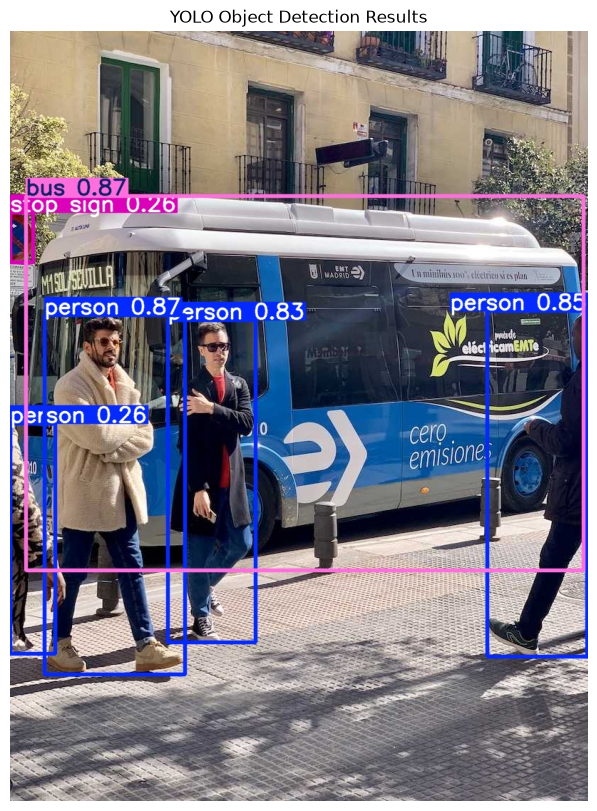

In [14]:
from ultralytics import YOLO
import matplotlib.pyplot as plt
import cv2
import os

# Load YOLOv8 model
model = YOLO("yolov8n.pt")   # যদি yolov11n.pt ব্যবহার করতে চাও তাহলে সেটার নাম দাও

# Run inference
results = model.predict(
    source=r"E:\ostad\bus.jpg",
    save=True,
    imgsz=640,
    conf=0.25
)

# Print detection results
for r in results:
    print("Detected Classes:")
    print(r.names)
    print(f"Annotated image saved in: {r.save_dir}")

# Path of saved image
annotated_image_path = os.path.join(results[0].save_dir, "bus.jpg")

# Read the image
img_bgr = cv2.imread(annotated_image_path)

# Check if image loaded successfully
if img_bgr is None:
    print("Error: Annotated image not found!")
else:
    # Convert BGR to RGB
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    # Display image
    plt.figure(figsize=(10, 10))
    plt.imshow(img_rgb)
    plt.axis("off")
    plt.title("YOLO Object Detection Results")
    plt.show()

### Interactive Confidence Threshold

Now, let's add an interactive slider to adjust the confidence threshold (`conf`). A higher threshold means the model needs to be more certain about a detection to show it, potentially reducing false positives but also possibly missing some true positives. A lower threshold will show more detections, including less certain ones.

Run the cell below, adjust the slider, and observe how the detected objects change.

## Object Detection on Video (Counting Cows)

In [17]:
import os

print(os.getcwd())
print(os.listdir())

e:\ostad\computer_vission
['cnn_fashion_mnist.ipynb', 'Computer_Vision_Examples.ipynb', 'istockphoto-1186020467-640_adpp_is.mp4', 'vehicles.mp4', 'vehicle_count_line.mp4', 'yolo11n-cls.pt', 'yolo11n-obb.pt', 'yolo11n-pose.pt', 'yolo11n-seg.pt', 'yolo11n.pt', 'yolov8n.pt', 'YOLO_demo.ipynb']


In [18]:
import cv2
from ultralytics import YOLO

# Load YOLO model
model = YOLO("yolov8n.pt")

# Video path (VS Code)
video_path = "istockphoto-1186020467-640_adpp_is.mp4"

cap = cv2.VideoCapture(video_path)

if not cap.isOpened():
    print("Error: Video could not be opened!")
    exit()

fps = int(cap.get(cv2.CAP_PROP_FPS))
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

output_video_path = "output_farm_cows.mp4"

fourcc = cv2.VideoWriter_fourcc(*"mp4v")
out = cv2.VideoWriter(output_video_path, fourcc, fps, (width, height))

frame_count = 0
max_frames = 300

while cap.isOpened() and frame_count < max_frames:

    ret, frame = cap.read()

    if not ret:
        break

    results = model.predict(frame, conf=0.25, verbose=False)

    cow_count = 0

    for r in results:

        for box in r.boxes:

            cls = int(box.cls[0])

            if model.names[cls] == "cow":
                cow_count += 1

        annotated_frame = r.plot()

    cv2.putText(
        annotated_frame,
        f"Cows: {cow_count}",
        (30, 50),
        cv2.FONT_HERSHEY_SIMPLEX,
        1,
        (0, 255, 0),
        2,
    )

    out.write(annotated_frame)

    frame_count += 1

cap.release()
out.release()

print("Finished!")
print("Output Video:", output_video_path)

Finished!
Output Video: output_farm_cows.mp4


In [19]:
# Re-encode the video to a temporary file using H.264
!ffmpeg -y -i /content/istockphoto-1186020467-640_adpp_is.mp4 \
    -c:v libx264 \
    -pix_fmt yuv420p \
    -movflags +faststart \
    /content/temp_video.mp4

# Replace the original file with the compatible one
!mv /content/temp_video.mp4 /content/istockphoto-1186020467-640_adpp_is.mp4

'ffmpeg' is not recognized as an internal or external command,
operable program or batch file.
'mv' is not recognized as an internal or external command,
operable program or batch file.
